In [42]:
# install pycaret
!pip install pycaret

In [43]:
#importing libraries that are relevant, this will allow me to manipulate data and merge tables
#renamed pandas as pd for short
import pandas as pd

In [44]:
#naming my file as data
#read the csv file
data1= pd.read_csv('/content/Cleaned Dataset1.csv')

In [45]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4241 entries, 0 to 4240
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0    no_of_dependents          4241 non-null   int64
 1    education                 4241 non-null   int64
 2    self_employed             4241 non-null   int64
 3    income_annum              4241 non-null   int64
 4    loan_amount               4241 non-null   int64
 5    loan_term                 4241 non-null   int64
 6    cibil_score               4241 non-null   int64
 7    residential_assets_value  4241 non-null   int64
 8    commercial_assets_value   4241 non-null   int64
 9    luxury_assets_value       4241 non-null   int64
 10   bank_asset_value          4241 non-null   int64
 11   loan_status               4241 non-null   int64
dtypes: int64(12)
memory usage: 397.7 KB


In [46]:
#this is importing a library from python preparing a model for training data
from sklearn.model_selection import train_test_split

In [47]:
# numpy and pandas will be used for data manipulation
import numpy as np
# matplotlib will be used for visually representing our data
import matplotlib.pyplot as plt

In [48]:
# Expand truncated values in pandas data frame
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 100)

In [49]:
data1 = data1.sample(frac=0.7, random_state=500)
data1_unseen = data1.drop(data1.index)

data1.reset_index(drop=True, inplace=True)
data1_unseen.reset_index(drop=True, inplace=True)

print('Data for Modeling: ' + str(data1.shape))
print('Unseen Data For Predictions: ' + str(data1_unseen.shape))

Data for Modeling: (2969, 12)
Unseen Data For Predictions: (0, 12)


In [50]:
from pycaret.classification import *
prediction= setup(data1,target = ' loan_status',
                fold_strategy = 'kfold',
                fold = 5,
                data_split_stratify = True ,
                normalize = True,
                normalize_method ='minmax',
                low_variance_threshold = 0.1,
                numeric_imputation ='mean',
                session_id = 43)


,Description,Value
0,Session id,43
1,Target,loan_status
2,Target type,Binary
3,Target mapping,"1: 0, 2: 1"
4,Original data shape,"(2969, 12)"
5,Transformed data shape,"(2969, 12)"
6,Transformed train set shape,"(2078, 12)"
7,Transformed test set shape,"(891, 12)"
8,Numeric features,11
9,Preprocess,True


In [51]:
# To get a list of all possible checks on configurations
get_config()

{'USI',
 'X',
 'X_test',
 'X_test_transformed',
 'X_train',
 'X_train_transformed',
 'X_transformed',
 '_available_plots',
 '_ml_usecase',
 'data',
 'dataset',
 'dataset_transformed',
 'exp_id',
 'exp_name_log',
 'fix_imbalance',
 'fold_generator',
 'fold_groups_param',
 'fold_shuffle_param',
 'gpu_n_jobs_param',
 'gpu_param',
 'html_param',
 'idx',
 'is_multiclass',
 'log_plots_param',
 'logging_param',
 'memory',
 'n_jobs_param',
 'pipeline',
 'seed',
 'target_param',
 'test',
 'test_transformed',
 'train',
 'train_transformed',
 'variable_and_property_keys',
 'variables',
 'y',
 'y_test',
 'y_test_transformed',
 'y_train',
 'y_train_transformed',
 'y_transformed'}

In [52]:
# compare all models
best_model = compare_models(sort = 'Accuracy')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9793,0.9970,0.9793,0.9794,0.9793,0.9558,0.9559,0.6880
xgboost,Extreme Gradient Boosting,0.9774,0.9982,0.9774,0.9774,0.9774,0.9518,0.9518,0.0980
gbc,Gradient Boosting Classifier,0.9764,0.9974,0.9764,0.9765,0.9764,0.9497,0.9498,0.6180
lightgbm,Light Gradient Boosting Machine,0.9755,0.9980,0.9755,0.9756,0.9754,0.9475,0.9477,0.2040
dt,Decision Tree Classifier,0.9731,0.9708,0.9731,0.9731,0.9730,0.9425,0.9426,0.1600
ada,Ada Boost Classifier,0.9711,0.9947,0.9711,0.9712,0.9711,0.9384,0.9385,0.4760
et,Extra Trees Classifier,0.9553,0.9905,0.9553,0.9552,0.9552,0.9044,0.9045,0.3040
qda,Quadratic Discriminant Analysis,0.9254,0.9753,0.9254,0.9260,0.9256,0.8419,0.8422,0.1060
nb,Naive Bayes,0.9230,0.9638,0.9230,0.9235,0.9231,0.8365,0.8368,0.0880
lda,Linear Discriminant Analysis,0.9196,0.9650,0.9196,0.9217,0.9201,0.8309,0.8320,0.0480


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [53]:
#To view all available algorithms
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [54]:
# to create a KNN model with k=5
knn=create_model('knn',n_neighbors = 5 , metric = 'manhattan')


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8918,0.9576,0.8918,0.8923,0.8920,0.7718,0.7719
1,0.8534,0.9168,0.8534,0.8527,0.8529,0.6876,0.6879
2,0.9135,0.9649,0.9135,0.9132,0.9131,0.8163,0.8167
3,0.8651,0.9419,0.8651,0.8655,0.8652,0.7109,0.7109
4,0.8819,0.9426,0.8819,0.8825,0.8822,0.7453,0.7454
Mean,0.8811,0.9448,0.8811,0.8812,0.8811,0.7464,0.7466
Std,0.0209,0.0165,0.0209,0.0210,0.0209,0.0453,0.0453


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [55]:
evaluate_model(knn)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [56]:
# Tune the KNN model
tuned_knn = tune_model(knn)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9207,0.9730,0.9207,0.9207,0.9202,0.8302,0.8311
1,0.8774,0.9559,0.8774,0.8768,0.8768,0.7382,0.7387
2,0.9183,0.9812,0.9183,0.9200,0.9172,0.8241,0.8277
3,0.8940,0.9697,0.8940,0.8936,0.8937,0.7710,0.7712
4,0.9084,0.9746,0.9084,0.9080,0.9080,0.7999,0.8003
Mean,0.9038,0.9709,0.9038,0.9038,0.9032,0.7927,0.7938
Std,0.0162,0.0084,0.0162,0.0167,0.0161,0.0343,0.0350


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [57]:
#to see hyperparameterers before tuning
print(knn)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='manhattan',
                     metric_params=None, n_jobs=-1, n_neighbors=5, p=2,
                     weights='uniform')


In [58]:
# To view the knn hyperparameters after tuning
print(tuned_knn)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='manhattan',
                     metric_params=None, n_jobs=-1, n_neighbors=28, p=2,
                     weights='distance')


In [59]:
#Graphical plot of tuned KNN
evaluate_model(tuned_knn)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [60]:
#Tune the Gradient Boosting Classifer
tuned_best_model=tune_model(best_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9760,0.9952,0.9760,0.9760,0.9760,0.9491,0.9491
1,0.9615,0.9967,0.9615,0.9617,0.9616,0.9188,0.9188
2,0.9784,0.9989,0.9784,0.9795,0.9785,0.9549,0.9558
3,0.9711,0.9966,0.9711,0.9712,0.9711,0.9381,0.9381
4,0.9735,0.9973,0.9735,0.9737,0.9735,0.9428,0.9429
Mean,0.9721,0.9969,0.9721,0.9724,0.9721,0.9407,0.9410
Std,0.0058,0.0012,0.0058,0.0060,0.0058,0.0124,0.0126


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [61]:
# Perform a direct test of the best_model on the test set
predict_model(best_model)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9630,0.9966,0.9630,0.9629,0.9629,0.9209,0.9210


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,prediction_label,prediction_score
78,0,1,2,4,14,0,321,4,4,17,2,1,1,0.96
1941,4,1,1,95,247,1,242,98,120,290,133,2,1,0.63
960,0,2,1,18,56,5,600,38,24,68,30,1,1,1.00
1281,3,2,2,1,3,2,596,3,4,3,4,1,1,0.94
1490,2,1,2,96,251,0,355,199,46,210,79,1,1,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2341,1,1,2,6,26,3,382,22,11,26,7,1,1,0.99
541,0,2,2,15,54,5,122,34,11,62,9,2,2,0.98
1879,1,1,2,8,33,1,270,10,13,34,10,1,1,0.98
1080,1,2,2,94,280,2,236,187,93,270,60,2,2,0.93


In [62]:
# Create a Linear Regression model
lr = create_model('lr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9014,0.9631,0.9014,0.9013,0.9007,0.7885,0.7898
1,0.8822,0.9559,0.8822,0.8817,0.8817,0.7485,0.7490
2,0.9159,0.9722,0.9159,0.9157,0.9155,0.8212,0.8218
3,0.9036,0.9638,0.9036,0.9039,0.9037,0.7935,0.7935
4,0.9253,0.9663,0.9253,0.9252,0.9252,0.8379,0.8380
Mean,0.9057,0.9643,0.9057,0.9056,0.9054,0.7979,0.7984
Std,0.0146,0.0053,0.0146,0.0147,0.0147,0.0307,0.0305


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [63]:
tuned_lr = tune_model(lr)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9303,0.9636,0.9303,0.9324,0.9307,0.8543,0.8556
1,0.8966,0.9571,0.8966,0.9006,0.8974,0.7850,0.7872
2,0.9207,0.9731,0.9207,0.9223,0.9210,0.8345,0.8354
3,0.9036,0.9646,0.9036,0.9100,0.9047,0.7984,0.8025
4,0.9253,0.9666,0.9253,0.9284,0.9259,0.8412,0.8430
Mean,0.9153,0.9650,0.9153,0.9187,0.9159,0.8227,0.8247
Std,0.0129,0.0051,0.0129,0.0118,0.0128,0.0264,0.0257


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


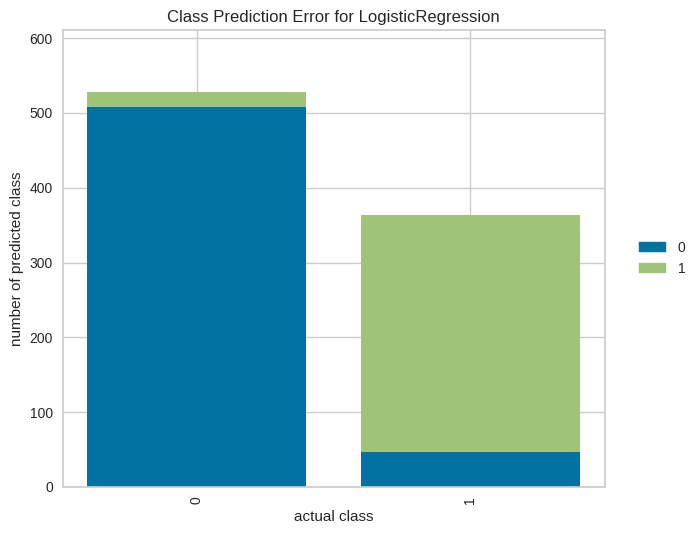

In [65]:
 plot_model(tuned_lr, plot = 'error')

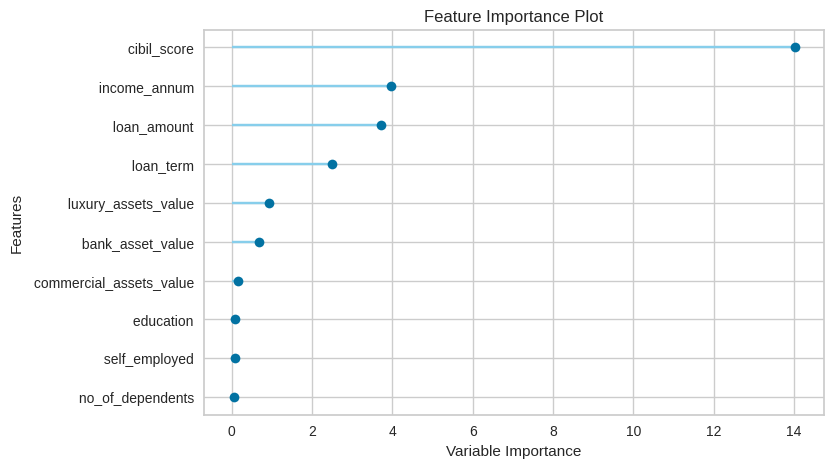

In [66]:
plot_model(tuned_lr, plot='feature')

In [67]:
evaluate_model(tuned_lr)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [68]:
predict_model(tuned_lr);

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9248,0.9681,0.9248,0.9276,0.9253,0.8424,0.8441


In [69]:
final_lr= finalize_model(tuned_lr)
print(final_lr)

Pipeline(memory=Memory(location=None),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=[' no_of_dependents', ' education',
                                             ' self_employed', ' income_annum',
                                             ' loan_amount', ' loan_term',
                                             ' cibil_score',
                                             ' residential_assets_value',
                                             ' commercial...
                 TransformerWrapper(exclude=None, include=None,
                                    transformer=CleanColumnNames(match='[\\]\\[\\,\\{\\}\\"\\:]+'))),
                ('actual_estimator',
                 LogisticRegression(C=9.889, class_w

In [72]:
save_model(final_lr,'LR Model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=[' no_of_dependents', ' education',
                                              ' self_employed', ' income_annum',
                                              ' loan_amount', ' loan_term',
                                              ' cibil_score',
                                              ' residential_assets_value',
                                              ' commercial...
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=CleanColumnNames(match='[\\]\\[\\,\\{\\}\\"\\:]+'))),
                 ('actual_estimator',
                  LogisticRegression(

In [73]:
rf = create_model('rf')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9808,0.9928,0.9808,0.9808,0.9808,0.9593,0.9593
1,0.9663,0.9969,0.9663,0.9663,0.9663,0.9286,0.9286
2,0.9880,0.9995,0.9880,0.9883,0.9880,0.9748,0.9751
3,0.9807,0.9979,0.9807,0.9807,0.9807,0.9585,0.9585
4,0.9807,0.9979,0.9807,0.9808,0.9807,0.9580,0.9582
Mean,0.9793,0.9970,0.9793,0.9794,0.9793,0.9558,0.9559
Std,0.0071,0.0022,0.0071,0.0072,0.0071,0.0150,0.0151


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [74]:
tuned_rf = tune_model(rf)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9760,0.9952,0.9760,0.9760,0.9760,0.9491,0.9491
1,0.9615,0.9967,0.9615,0.9617,0.9616,0.9188,0.9188
2,0.9784,0.9989,0.9784,0.9795,0.9785,0.9549,0.9558
3,0.9711,0.9966,0.9711,0.9712,0.9711,0.9381,0.9381
4,0.9735,0.9973,0.9735,0.9737,0.9735,0.9428,0.9429
Mean,0.9721,0.9969,0.9721,0.9724,0.9721,0.9407,0.9410
Std,0.0058,0.0012,0.0058,0.0060,0.0058,0.0124,0.0126


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [75]:
print(tuned_rf)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=43, verbose=0,
                       warm_start=False)


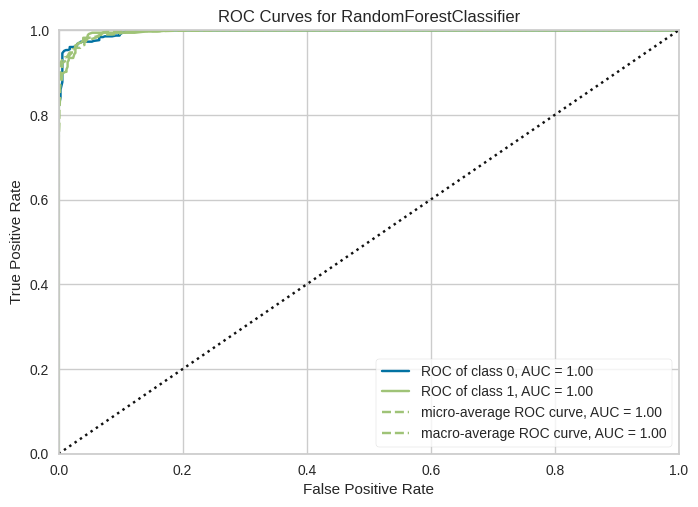

In [76]:
plot_model(tuned_rf)

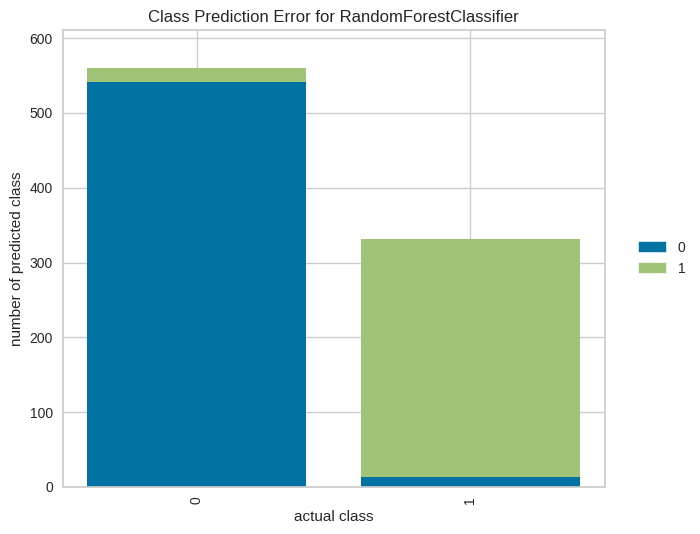

In [77]:
plot_model(tuned_rf, plot = 'error')

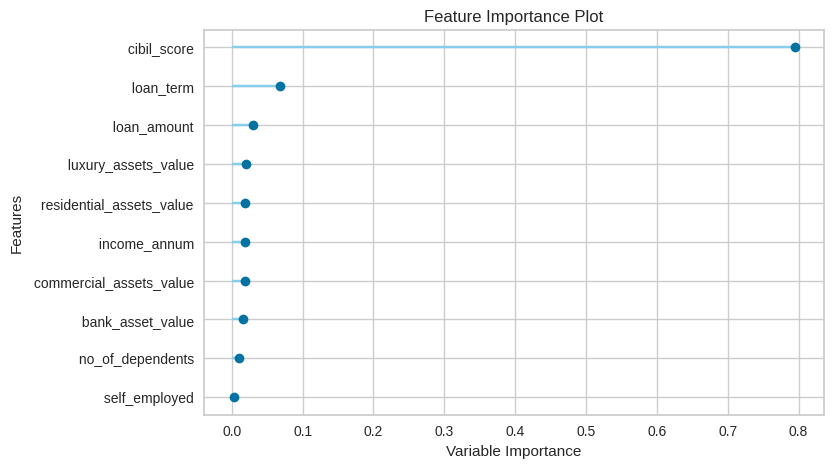

In [78]:
plot_model(tuned_rf, plot = 'feature')

In [79]:
evaluate_model(tuned_rf)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [80]:
predict_model(tuned_rf)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9630,0.9966,0.9630,0.9629,0.9629,0.9209,0.9210


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,prediction_label,prediction_score
78,0,1,2,4,14,0,321,4,4,17,2,1,1,0.96
1941,4,1,1,95,247,1,242,98,120,290,133,2,1,0.63
960,0,2,1,18,56,5,600,38,24,68,30,1,1,1.00
1281,3,2,2,1,3,2,596,3,4,3,4,1,1,0.94
1490,2,1,2,96,251,0,355,199,46,210,79,1,1,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2341,1,1,2,6,26,3,382,22,11,26,7,1,1,0.99
541,0,2,2,15,54,5,122,34,11,62,9,2,2,0.98
1879,1,1,2,8,33,1,270,10,13,34,10,1,1,0.98
1080,1,2,2,94,280,2,236,187,93,270,60,2,2,0.93


In [81]:
final_rf = finalize_model(tuned_rf)

In [82]:
predict_model(final_rf)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,prediction_label,prediction_score
78,0,1,2,4,14,0,321,4,4,17,2,1,1,0.96
1941,4,1,1,95,247,1,242,98,120,290,133,2,2,0.82
960,0,2,1,18,56,5,600,38,24,68,30,1,1,0.98
1281,3,2,2,1,3,2,596,3,4,3,4,1,1,0.99
1490,2,1,2,96,251,0,355,199,46,210,79,1,1,0.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2341,1,1,2,6,26,3,382,22,11,26,7,1,1,0.99
541,0,2,2,15,54,5,122,34,11,62,9,2,2,0.98
1879,1,1,2,8,33,1,270,10,13,34,10,1,1,1.00
1080,1,2,2,94,280,2,236,187,93,270,60,2,2,0.98
